In [12]:
import sys
from pathlib import Path 
import math
import pickle
import bisect
import numpy as np
import time

from dataclasses import dataclass
import random
from collections import defaultdict

HW = 3
N = 9
M = 20
K = 81
INF = 10**18
MOD = 998244353
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False

def fastcopy(obj):
    return pickle.loads(pickle.dumps(obj, -1))

def debug_print(*args, **kwargs):
    if not ONLINE_JUDGE:
        print(*args, **kwargs)

In [13]:
class Env:
    def __init__(self, input_txt_path: Path):
        self.grid, self.stamps = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        grid = []
        for i in range(1, 1+N):
            d = list(map(int, lines[i].split()))
            grid.append(d)
        stamps = []
        for i in range(1+N, 1+N+M*HW, 3):
            tmp_stamp = []
            for j in range(HW):
                d = list(map(int, lines[i+j].split()))
                tmp_stamp.append(d)
            stamps.append(tmp_stamp)
        return grid, stamps

    def print_grid(self):
        for d in self.grid:
            print(d)
    
    def pring_stamps(self):
        for s in self.stamps:
            for d in s:
                print(d)
            print()

In [14]:
def evaluate_score(grid: list[list[int]]) -> int:
    s = 0
    for h in range(N):
        for w in range(N):
            s += grid[h][w] % MOD
    return s

In [15]:
def evaluate_score2(grid: list[list[int]], env :Env, remain_k: int):
    
    now_remain_k = remain_k
    total_score = 0
    for h1 in range(0, N, HW):
        for w1 in range(0, N, HW):
            diff_mod = [[0 for _ in range(HW)] for _ in range(HW)]
            for h in range(HW):
                for w in range(HW):
                    diff_mod[h][w] = (MOD - 1) - grid[h1+h][w1+w]
            max_tmp_score = 0
            max_k_and_score = (0, 0)
            for m in range(M):
                k_list = []
                for h in range(HW):
                    for w in range(HW):
                        k_list.append(diff_mod[h][w] // env.stamps[m][h][w])
                max_k = min(max(k_list), now_remain_k)
                tmp_score = 0
                for h in range(HW):
                    for w in range(HW):
                        tmp_score += grid[h1+h][w1+w] + env.stamps[m][h][w] * max_k
                if tmp_score > max_tmp_score:
                    max_tmp_score = tmp_score
                    max_k_and_score = (max_k, tmp_score)
            now_remain_k -= max_k_and_score[0]
            total_score += max_k_and_score[1]

    return total_score

In [16]:
def step(env: Env):
    score = evaluate_score(env.grid)
    ans = None
    for m1 in range(M):
        for h1 in range(N-3):
            for w1 in range(N-3):
                now_grid = fastcopy(env.grid)
                for h in range(HW):
                    for w in range(HW):
                        now_grid[h1+h][w1+w] = (now_grid[h1+h][w1+w] + env.stamps[m1][h][w]) % MOD
                tmp_score = evaluate_score(now_grid)
                if tmp_score > score:
                    score = tmp_score
                    ans = (m1, h1, w1)
    return ans

In [17]:
def step2(env: Env, k: int):
    score = evaluate_score2(env.grid, env, remain_k=K-k)
    ans = None
    for m1 in range(M):
        for h1 in range(N-3):
            for w1 in range(N-3):
                now_grid = fastcopy(env.grid)
                for h in range(HW):
                    for w in range(HW):
                        now_grid[h1+h][w1+w] = (now_grid[h1+h][w1+w] + env.stamps[m1][h][w]) % MOD
                tmp_score = evaluate_score2(now_grid, env, remain_k=K-k-1)
                if tmp_score > score:
                    score = tmp_score
                    ans = (m1, h1, w1)
    return ans

In [18]:
M * 6 * 6 * (81 * 20) * 81

94478400

In [19]:
def solve(env: Env):
    ans_list = []
    for k in range(K):
        # if k < K//2:
        #     ans = step2(env, k)
        # if k >= K//2 or ans is None:
        ans = step(env)
        if ans is None:
            debug_print("None", k)
            break
        ans_list.append(ans)
        m1, h1, w1 = ans
        for h in range(HW):
            for w in range(HW):
                env.grid[h1+h][w1+w] += env.stamps[m1][h][w]
    return ans_list


In [20]:
TEST_CASE_NUM = 100
scores = []
for i in range(TEST_CASE_NUM):
    debug_print(f"----- {i}/100 -----")
    input_txt_path = Path(f"./in/{str(i).zfill(4)}.txt")
    env = Env(input_txt_path)
    ans_list = solve(env)
    score = evaluate_score(env.grid)
    score = score / 10 ** 10
    print(score)
    scores.append(score)

----- 0/100 -----
None 12
5.6030286162
----- 1/100 -----
None 15
5.6652251968
----- 2/100 -----
None 13
5.6622135685
----- 3/100 -----
None 13
5.8485685698
----- 4/100 -----
None 18
5.8841185361
----- 5/100 -----
None 14
5.6772411247
----- 6/100 -----
None 17
5.9524775685
----- 7/100 -----
None 13
5.6565474422
----- 8/100 -----
None 9
5.6498518425
----- 9/100 -----
None 17
5.9708637733
----- 10/100 -----
None 12
5.6772394411
----- 11/100 -----
None 10
5.8482971311
----- 12/100 -----
None 14
5.6700570842
----- 13/100 -----
None 10
5.5345959219
----- 14/100 -----
None 15
5.799760842
----- 15/100 -----
None 14
6.220439915
----- 16/100 -----
None 10
5.7036638353
----- 17/100 -----
None 17
5.8035792661
----- 18/100 -----
None 13
5.6406535763
----- 19/100 -----
None 11
5.9769539671
----- 20/100 -----
None 15
5.6796281544
----- 21/100 -----
None 18
5.8835892073
----- 22/100 -----
None 18
5.9130069157
----- 23/100 -----
None 14
5.9624897852
----- 24/100 -----
None 10
5.6916379016
----- 25/100 

In [21]:
ave_score = sum(scores) / len(scores)
ave_score

5.809322747854001


In [22]:
ave_score * 150

87139.84121781001

<BarContainer object of 100 artists>

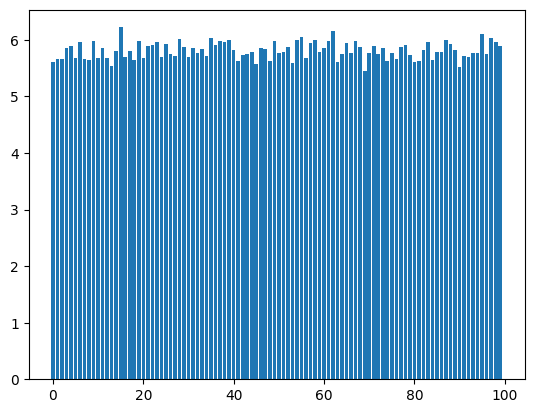

In [23]:
import matplotlib.pyplot as plt
plt.bar(range(TEST_CASE_NUM), scores)